In [39]:
!git clone https://github.com/Research-Methods-hackathon/Hackathon_GroupV.git


Cloning into 'Hackathon_GroupV'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 21 (delta 1), reused 21 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 178.97 KiB | 4.84 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [40]:
import os

folders = [
    "data",
    "notebooks",
    "outputs",
    "figures",
    "figures/eda_plots",
    "figures/model_plots",
    "models",
    "presentation_notes"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folder structure created successfully.")


Folder structure created successfully.


In [41]:
readme_files = {
    "README.md": "# Data Science Challenge - Dataset C\n\nThis repository contains the hackathon code, data, models, figures, outputs, and submission files.",
    "data/README.md": "# Data Folder\n\nTraining, testing, and example submission files are stored here.",
    "notebooks/README.md": "# Notebooks Folder\n\nColab/Jupyter notebooks used during the hackathon are stored here.",
    "outputs/README.md": "# Outputs Folder\n\nFinal prediction files and model comparison results are stored here.",
    "figures/README.md": "# Figures Folder\n\nEDA, model evaluation, and XAI figures are stored here.",
    "models/README.md": "# Models Folder\n\nSaved trained models are stored here.",
    "presentation_notes/README.md": "# Presentation Notes\n\nCritical analysis and presentation speaking notes are stored here."
}

for path, content in readme_files.items():
    with open(path, "w") as f:
        f.write(content)

print("README files created.")


README files created.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [43]:
train = pd.read_csv("/content/sample_data/dataset_C_training.csv")
test = pd.read_csv("/content/sample_data/dataset_C_testing.csv")
sample_submission = pd.read_csv("/content/sample_data/dataset_C_example_submission.csv")



In [46]:
print("Training shape:", train.shape)
print("Testing shape:", test.shape)
print("Example submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())




Training shape: (4756, 31)
Testing shape: (4749, 30)
Example submission shape: (4749, 2)


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,0,4,2,2.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,"MSA, Not Principle City",0.0,0.0,0,2,3,2.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,0,3,2,2.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Employed,Non-MSA,1.0,0.0,0,4,4,1.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,Non-MSA,0.0,0.0,0,3,2,1.0,wholesale


,respondent_id,covid_vaccine
0,4757,0.0
1,4758,0.0
2,4759,0.0
3,4760,0.0
4,4761,0.0


In [47]:
print(train.info())
display(train.describe(include="all"))

print("Missing values:")
display(train.isnull().sum().sort_values(ascending=False))

print("Duplicate rows:", train.duplicated().sum())

print("Target distribution:")
display(train["covid_vaccine"].value_counts())
display(train["covid_vaccine"].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 4624 non-null   float64
 13  hea

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
count,4756.00000,4744.000000,4729.000000,4742.000000,4729.000000,4754.000000,4747.000000,4746.000000,4742.000000,4735.000000,...,4518,4756,4717.000000,4717.000000,4756.000000,4756.000000,4756.000000,4666.000000,2426,4756.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,3,NaN,NaN,NaN,NaN,NaN,NaN,21,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Employed,"MSA, Not Principle City",NaN,NaN,NaN,NaN,NaN,NaN,healthcare,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2451,2104,NaN,NaN,NaN,NaN,NaN,NaN,527,NaN
mean,2378.50000,1.648609,1.296469,0.053353,0.733347,0.072991,0.839267,0.356300,0.329186,0.693981,...,NaN,NaN,0.893576,0.532542,0.227502,3.812447,2.489277,2.121732,NaN,0.326745
std,1373.08327,0.903204,0.615705,0.224760,0.442256,0.260149,0.367323,0.478956,0.469967,0.460886,...,NaN,NaN,0.763981,0.934933,0.419263,1.051633,1.261286,1.335704,NaN,0.469073
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,0.000000
25%,1189.75000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,NaN,0.000000,0.000000,0.000000,3.000000,1.000000,1.000000,NaN,0.000000
50%,2378.50000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,NaN,NaN,1.000000,0.000000,0.000000,4.000000,2.000000,2.000000,NaN,0.000000
75%,3567.25000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,1.000000,1.000000,0.000000,4.000000,4.000000,4.000000,NaN,1.000000


Missing values:


,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


Duplicate rows: 0
Target distribution:


,count
covid_vaccine,
0,3202
1,1554


,proportion
covid_vaccine,
0,0.673255
1,0.326745


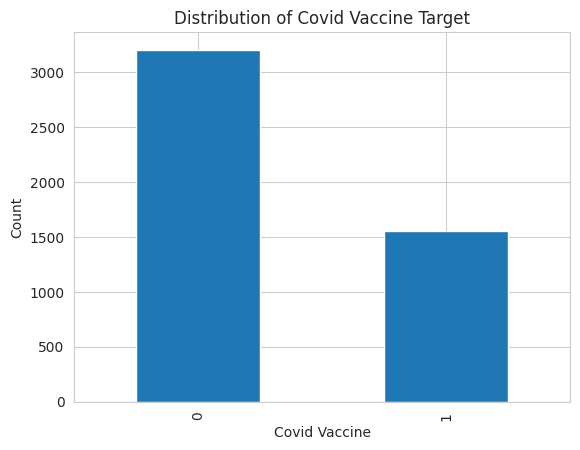

In [48]:
train["covid_vaccine"].value_counts().plot(kind="bar")
plt.title("Distribution of Covid Vaccine Target")
plt.xlabel("Covid Vaccine")
plt.ylabel("Count")
plt.savefig("figures/eda_plots/target_distribution.png", bbox_inches="tight")
plt.show()



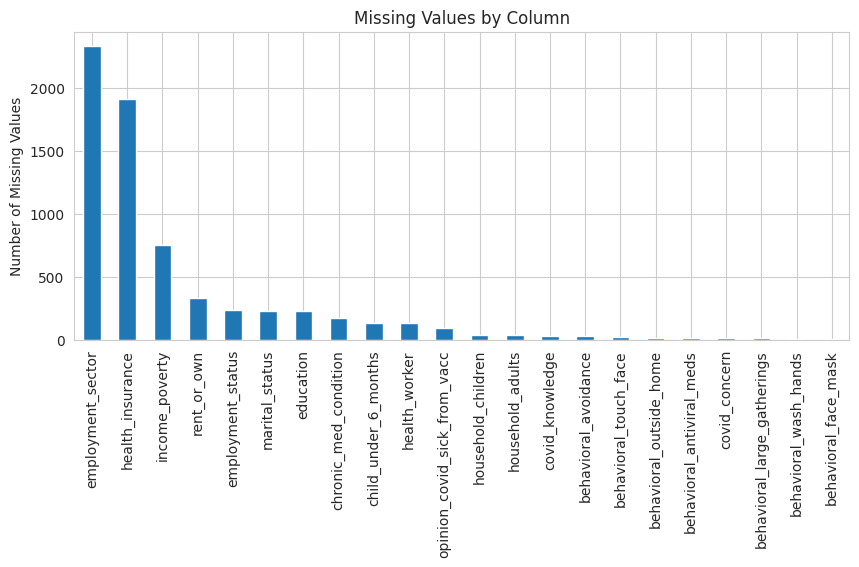

In [49]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
missing.plot(kind="bar")
plt.title("Missing Values by Column")
plt.ylabel("Number of Missing Values")
plt.savefig("figures/eda_plots/missing_values.png", bbox_inches="tight")
plt.show()


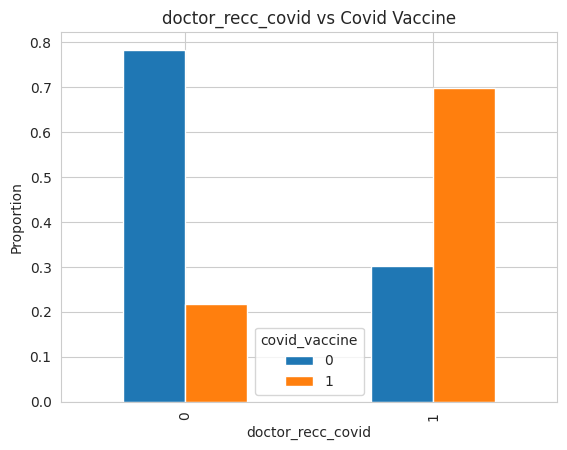

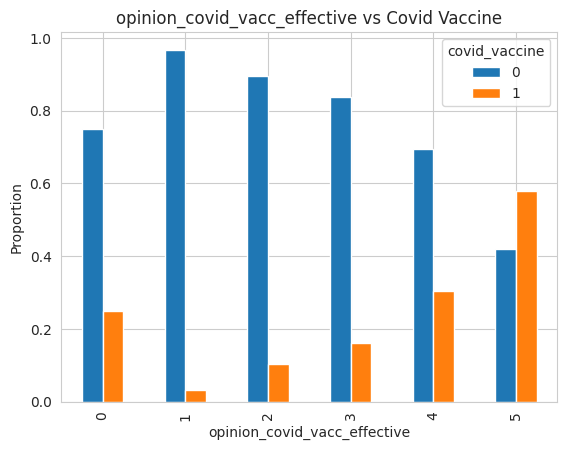

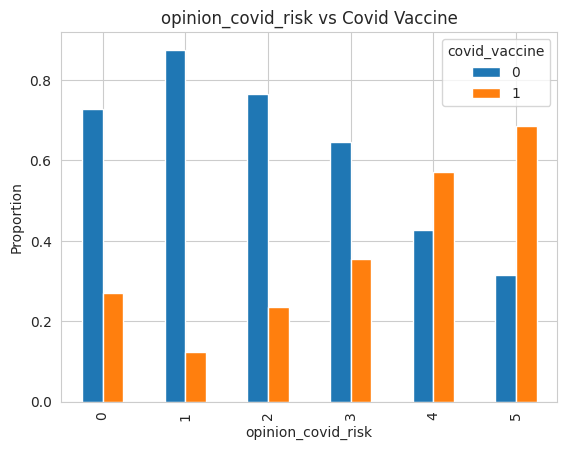

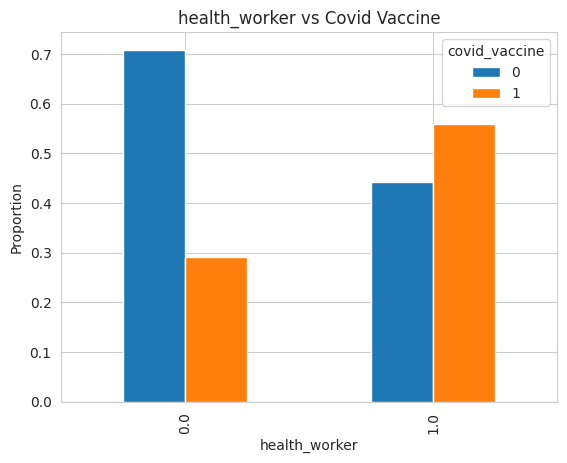

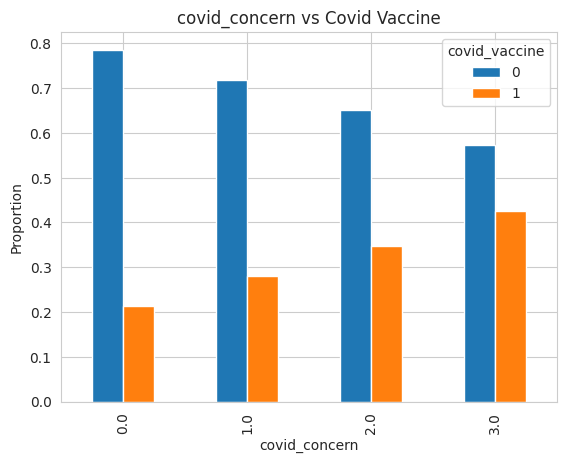

In [33]:
important_cols = [
    "doctor_recc_covid",
    "opinion_covid_vacc_effective",
    "opinion_covid_risk",
    "health_worker",
    "covid_concern"
]

for col in important_cols:
    pd.crosstab(train[col], train["covid_vaccine"], normalize="index").plot(kind="bar")
    plt.title(f"{col} vs Covid Vaccine")
    plt.ylabel("Proportion")
    plt.savefig(f"figures/eda_plots/{col}_vs_target.png", bbox_inches="tight")
    plt.show()


In [50]:
target = "covid_vaccine"
id_col = "respondent_id"

X = train.drop(columns=[target, id_col])
y = train[target]

X_test_final = test.drop(columns=[id_col])

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['covid_concern', 'covid_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'household_adults', 'household_children', 'doctor_recc_covid', 'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc']
Categorical columns: ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [51]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [52]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

# Validation predictions
valid_probs = rf_model.predict_proba(X_valid)[:, 1]
valid_preds = (valid_probs >= 0.5).astype(int)

print("Random Forest")
print("Accuracy:", accuracy_score(y_valid, valid_preds))
print("F1 Score:", f1_score(y_valid, valid_preds))
print("ROC-AUC:", roc_auc_score(y_valid, valid_probs))
print(classification_report(y_valid, valid_preds))

Random Forest
Accuracy: 0.7836134453781513
F1 Score: 0.6113207547169811
ROC-AUC: 0.8186866381407669
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       641
           1       0.74      0.52      0.61       311

    accuracy                           0.78       952
   macro avg       0.77      0.72      0.73       952
weighted avg       0.78      0.78      0.77       952



In [55]:
# Test probabilities for final submission
test_probs = rf_model.predict_proba(X_test_final)[:, 1]

RandomForestValues = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "covid_vaccine": test_probs
})

RandomForestValues.head()

,respondent_id,covid_vaccine
0,4757,0.2150
1,4758,0.1225
2,4759,0.1850
3,4760,0.2550
4,4761,0.0525


In [56]:
RandomForestValues.to_csv(
    "outputs/RandomForestValues.csv",
    index=False
)

print("RandomForestValues.csv saved successfully")

RandomForestValues.csv saved successfully


In [57]:
pd.read_csv("outputs/RandomForestValues.csv").head()

,respondent_id,covid_vaccine
0,4757,0.2150
1,4758,0.1225
2,4759,0.1850
3,4760,0.2550
4,4761,0.0525


In [58]:
!ls outputs

RandomForestValues.csv	README.md
